# Прогноз риска задержки доставки CargaPronto

В проекте решается задача для логистической компании CargaPronto: заранее определить, какие заказы имеют высокий риск задержки доставки. По данным внутреннего аудита, значительная доля заказов нарушает SLA, что приводит к штрафам и риску потери крупных клиентов.

Цель исследования — проверить, связаны ли задержки не только с операционными сбоями, но и с профилем клиента: географией, покупательским поведением, частотой заказов, суммой покупок, скидками и долей возвратов. Для этого клиентская база будет сегментирована методами обучения без учителя, а полученные сегменты будут использованы как признаки в модели бинарной классификации.

## Основные гипотезы

1. **География клиента влияет на риск задержки.**  
   Клиенты из отдельных логистических зон могут чаще получать заказы с опозданием из-за сложности маршрутов или удаленности.

2. **Поведенческий профиль клиента связан с задержками.**  
   Частота заказов, давность последней покупки, суммарная выручка, средняя скидка и доля возвратов могут отражать группы клиентов с разным уровнем логистического риска.

3. **Кластеризация клиентов улучшит качество прогноза.**  
   Географические и RFM-сегменты могут дать модели дополнительный контекст и повысить ROC-AUC по сравнению с базовой моделью без кластерных признаков.

4. **Модель может быть полезна для принятия операционных решений.**  
   Если заказ заранее получает высокий риск задержки, логисты могут изменить приоритет сборки, выбрать более быстрый способ доставки, усилить маршрут или заранее уведомить клиента.

## Задача машинного обучения

Необходимо построить модель бинарной классификации, предсказывающую признак `late_delivery_risk`:

- `1` — заказ доставлен с задержкой;
- `0` — заказ доставлен вовремя.

Качество модели будет оцениваться по метрике **ROC-AUC**. Удовлетворительным результатом считается значение выше `0.75`.

В работе будут сравнены базовые модели и модели с дополнительными признаками кластеризации, чтобы оценить, дают ли клиентские сегменты реальную пользу для прогноза риска задержки.

## Аналитический фокус проверки

Бизнес-гипотеза CargaPronto не сводится к вопросу «есть ли задержки»: задержки уже массовые. Важнее понять, можно ли заранее выделить заказы, где риск нарушения SLA управляем через операционные действия: смену приоритета, ускорение доставки, усиление маршрута или проактивное уведомление клиента.

Проверка строится в два слоя:

1. Сначала оценивается, насколько риск объясняется признаками самого заказа: способом доставки, категорией товара, временем оформления и ценой.
2. Затем проверяется, добавляют ли клиентские сегменты новый сигнал: географическая зона, RFM-профиль, скидочная чувствительность и история возвратов.

Если клиентские сегменты дадут прирост ROC-AUC относительно базовой модели, это будет означать, что задержки частично связаны с типом клиента и зоной обслуживания, а не только с текущей загрузкой логистики.


In [1]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (
    GroupShuffleSplit
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer
)

from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier, Pool

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)


from sklearn.base import BaseEstimator, TransformerMixin


import phik
import optuna
from optuna.visualization import plot_optimization_history

import shap

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

/Users/average/Desktop/учеба/projects/module-5-unsupervised/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Загрузка данных, первичное знакомство

In [2]:
try: 
    customers = pd.read_csv("/datasets/ds_s18_customers.csv")
    orders = pd.read_csv("/datasets/ds_s18_orders.csv")
except FileNotFoundError:
    customers = pd.read_csv("https://code.s3.yandex.net/datasets/ds_s18_customers.csv")
    orders = pd.read_csv("https://code.s3.yandex.net/datasets/ds_s18_orders.csv")

data = {
    "customers": customers,
    "orders": orders
}

for name, df in data.items():
    print(f"{'=' * 10} {name} {'=' * 10}")
    display(pd.concat([df.head(), df.tail(), df.sample(5)]))
    print(df.shape)


========== customers ==========


,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,1,25.9536,-97.5077,472.4500,1,0.0600,0.0000,793
1,2,38.3756,-104.7260,1618.6600,4,0.1260,0.0000,137
2,3,18.0254,-66.6151,3189.2000,5,0.1050,0.0000,230
3,4,33.6700,-112.2471,1480.7100,4,0.1350,0.0000,381
4,5,18.3591,-66.0779,1101.9200,3,0.1400,0.0000,458
20647,20753,18.2730,-66.0371,161.8700,1,0.2500,0.0000,1
20648,20754,41.6086,-88.2020,172.6600,1,0.2000,0.0000,1
20649,20755,18.2515,-66.0371,314.6400,1,0.0400,0.0000,1
20650,20756,41.8308,-87.8030,10.9100,1,0.0600,0.0000,1
20651,20757,25.8603,-80.1973,34.9800,1,0.1200,0.0000,1


(20652, 8)
========== orders ==========


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.7500
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.7500
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.7500
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.7500
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.7500
180514,65177,1005,0,Standard Class,Fishing,2016-01-16 03:40:00,399.9800
180515,65161,9141,1,Second Class,Fishing,2016-01-16 01:34:00,399.9800
180516,65129,291,1,Standard Class,Fishing,2016-01-15 21:00:00,399.9800
180517,65126,2813,0,Standard Class,Fishing,2016-01-15 20:18:00,399.9800
180518,65113,7547,0,Standard Class,Fishing,2016-01-15 18:54:00,399.9800


(180519, 7)


In [3]:
def eda(df):
    eda_cols = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'nulls': df.isna().sum(),
    'null_pct': (df.isna().mean() * 100).round(2),
    'nunique': df.nunique(dropna=True),
    'nunique_pct': (df.nunique(dropna=True) / len(df) * 100).round(2),
    "duplicates": df.duplicated().sum(),
    "duplicates_pct": (df.duplicated().mean() * 100).round(2),
    }).reset_index().rename(columns={'index': 'column'})
    display(eda_cols)
for name, df in data.items():
    print("=" * 100)
    print(name)
    print("=" * 100)
    eda(df)

customers


,column,dtype,nulls,null_pct,nunique,nunique_pct,duplicates,duplicates_pct
0,customer_id,int64,0,0.0000,20652,100.0000,0,0.0000
1,customer_lat,float64,0,0.0000,12767,61.8200,0,0.0000
2,customer_lon,float64,0,0.0000,6161,29.8300,0,0.0000
3,total_sales,float64,0,0.0000,12632,61.1700,0,0.0000
4,total_orders,int64,0,0.0000,15,0.0700,0,0.0000
5,avg_discount,float64,0,0.0000,10600,51.3300,0,0.0000
6,return_rate,float64,0,0.0000,166,0.8000,0,0.0000
7,recency,int64,0,0.0000,1012,4.9000,0,0.0000


orders


,column,dtype,nulls,null_pct,nunique,nunique_pct,duplicates,duplicates_pct
0,order_id,int64,0,0.0000,180519,100.0000,0,0.0000
1,customer_id,int64,0,0.0000,20652,11.4400,0,0.0000
2,late_delivery_risk,int64,0,0.0000,2,0.0000,0,0.0000
3,shipping_mode,str,0,0.0000,4,0.0000,0,0.0000
4,category_name,str,0,0.0000,50,0.0300,0,0.0000
5,order_date,str,0,0.0000,65752,36.4200,0,0.0000
6,item_price,float64,0,0.0000,75,0.0400,0,0.0000


In [4]:
for name, df in data.items():
    print(f"{'=' * 10} {name} {'=' * 10}")
    display(df.describe(include='all').T)

========== customers ==========


,count,mean,std,min,25%,50%,75%,max
customer_id,20652.0000,10400.2859,5993.1062,1.0000,5208.7500,10407.5000,15594.2500,20757.0000
customer_lat,20652.0000,29.7487,9.8241,-33.9376,18.2661,33.2164,39.2922,48.7819
customer_lon,20652.0000,-84.9501,21.2539,-158.0260,-98.4693,-76.7596,-66.3706,115.2631
total_sales,20652.0000,1600.5424,1508.4180,8.4700,254.9400,1294.5050,2621.1400,9436.6101
total_orders,20652.0000,3.1838,2.4307,1.0000,1.0000,3.0000,5.0000,15.0000
avg_discount,20652.0000,0.1017,0.0483,0.0000,0.0762,0.1000,0.1230,0.2500
return_rate,20652.0000,0.0430,0.1566,0.0000,0.0000,0.0000,0.0000,1.0000
recency,20652.0000,221.0891,199.3954,1.0000,76.0000,160.0000,308.0000,1126.0000


========== orders ==========


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,180519.0000,NaN,NaN,NaN,90260.0000,52111.4910,1.0000,45130.5000,90260.0000,135389.5000,180519.0000
customer_id,180519.0000,NaN,NaN,NaN,6691.3795,4162.9181,1.0000,3258.5000,6457.0000,9779.0000,20757.0000
late_delivery_risk,180519.0000,NaN,NaN,NaN,0.5483,0.4977,0.0000,0.0000,1.0000,1.0000,1.0000
shipping_mode,180519,4,Standard Class,107752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_name,180519,50,Cleats,24551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,180519,65752,2016-10-25 14:39:00,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_price,180519.0000,NaN,NaN,NaN,141.2325,139.7325,9.9900,50.0000,59.9900,199.9900,1999.9900


In [5]:
customer_summary = pd.DataFrame({
    "metric": [
        "customers_count",
        "orders_count",
        "one_order_customers_share",
        "median_total_orders",
        "p99_total_orders",
        "median_total_sales",
        "mean_total_sales",
        "p99_total_sales",
    ],
    "value": [
        len(customers),
        len(orders),
        (customers["total_orders"] == 1).mean(),
        customers["total_orders"].median(),
        customers["total_orders"].quantile(0.99),
        customers["total_sales"].median(),
        customers["total_sales"].mean(),
        customers["total_sales"].quantile(0.99),
    ],
})

customer_summary


,metric,value
0,customers_count,20652.0000
1,orders_count,180519.0000
2,one_order_customers_share,0.4302
3,median_total_orders,3.0000
4,p99_total_orders,10.0000
5,median_total_sales,1294.5050
6,mean_total_sales,1600.5424
7,p99_total_sales,5818.8553


### Вывод: качество и структура исходных данных

Данные пригодны для анализа без первичного восстановления: пропусков и полных дублей нет. Объем достаточный для устойчивого сравнения моделей: 20 652 клиента и 180 519 заказов.

Клиентская база неоднородна. 43.02% клиентов сделали только один заказ, медианный клиент сделал 3 заказа, а 99-й процентиль — 10 заказов. Значит, в базе одновременно есть разовые покупатели и небольшая группа более активных клиентов.

По выручке также есть сильная асимметрия: медианная суммарная выручка клиента — 1293.69, средняя — 1599.83, 99-й процентиль — 5817.71. 

In [6]:
orders["customer_id"].isin(customers["customer_id"]).all()

np.True_

In [7]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

orders["order_month"] = orders["order_date"].dt.month
orders["order_weekday_num"] = orders["order_date"].dt.weekday
orders["order_hour"] = orders["order_date"].dt.hour

In [8]:
monthly_risk = (
    orders.groupby("order_month")["late_delivery_risk"]
    .agg(orders_count="count", delay_rate="mean")
    .sort_values("delay_rate", ascending=False)
)

hourly_risk = (
    orders.groupby("order_hour")["late_delivery_risk"]
    .agg(orders_count="count", delay_rate="mean")
    .sort_values("delay_rate", ascending=False)
)

print("Месяцы с максимальным риском задержки:")
display(monthly_risk.head())

print("Месяцы с минимальным риском задержки:")
display(monthly_risk.tail())

print("Часы с максимальным риском задержки:")
display(hourly_risk.head())

print("Часы с минимальным риском задержки:")
display(hourly_risk.tail())


Месяцы с максимальным риском задержки:


,orders_count,delay_rate
order_month,,
8,15912,0.5579
12,12764,0.5534
9,15489,0.5530
3,15919,0.5525
6,15139,0.5483


Месяцы с минимальным риском задержки:


,orders_count,delay_rate
order_month,,
10,12955,0.5460
2,14529,0.5455
11,12500,0.5455
4,15435,0.5428
7,15922,0.5406


Часы с максимальным риском задержки:


,orders_count,delay_rate
order_hour,,
12,7486,0.5950
20,7481,0.5912
22,7418,0.5848
23,7573,0.5806
15,7472,0.5798


Часы с минимальным риском задержки:


,orders_count,delay_rate
order_hour,,
0,7590,0.5148
4,7719,0.5147
11,7497,0.5106
6,7270,0.5095
8,7435,0.5087


### Вывод: временные признаки

Временные признаки нужны не как самостоятельное бизнес-объяснение, а как контроль операционного контекста. По текущим данным месяцы отличаются слабо: риск задержки колеблется примерно от 54.04% в июле до 55.77% в августе. Это не похоже на сильную сезонность

По часу заказа различия заметнее: около 50.73% задержек в 6 утра против 59.62% в 12 часов и 59.25% в 20 часов. Это может отражать нагрузку на складские или диспетчерские процессы в отдельные временные окна


In [9]:
def graphics_numerical(df, column):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df[column], kde=True, ax=axes[0])
    axes[0].set_title(f'Распределение признака: {column}')
    axes[0].set_xlabel('Значения')
    axes[0].set_ylabel('Количество')

    sns.boxplot(x=df[column], ax=axes[1])
    axes[1].set_title(f'Boxplot: {column}')
    axes[1].set_xlabel('Значения')
    axes[1].set_ylabel('Количество')

    plt.tight_layout()
    plt.show()

def graphics_numerical_cat(df, column):
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=df[column])
    plt.title(F"Распределение признака {column}")
    plt.xlabel("Уникальные значения")
    plt.ylabel("Количество")
    plt.show()

    print(f'Распределение {column}, количество и доля')
    share_target = df[column].value_counts(normalize=True)
    absolut_target = df[column].value_counts(dropna=False)
    target_values = pd.concat([absolut_target, share_target], axis=1)
    target_values.columns = ['Количество', 'Доля']
    display(target_values)

In [10]:
num_cat_o = ["late_delivery_risk", "order_month", "order_weekday_num", "order_hour"]
num_cols_o = ["item_price"]
cat_cols_o = ["shipping_mode", "category_name"]

num_cat_c = ["total_orders"]
num_cols_c = ["total_sales", "avg_discount", "return_rate", "recency"]

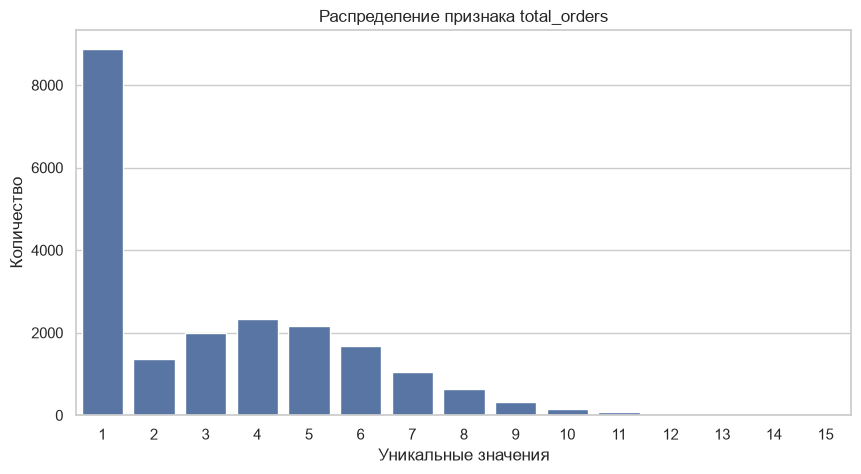

Распределение total_orders, количество и доля


,Количество,Доля
total_orders,,
1,8884,0.4302
4,2324,0.1125
5,2172,0.1052
3,1988,0.0963
6,1668,0.0808
2,1363,0.0660
7,1042,0.0505
8,627,0.0304
9,325,0.0157


In [11]:
graphics_numerical_cat(customers, "total_orders")

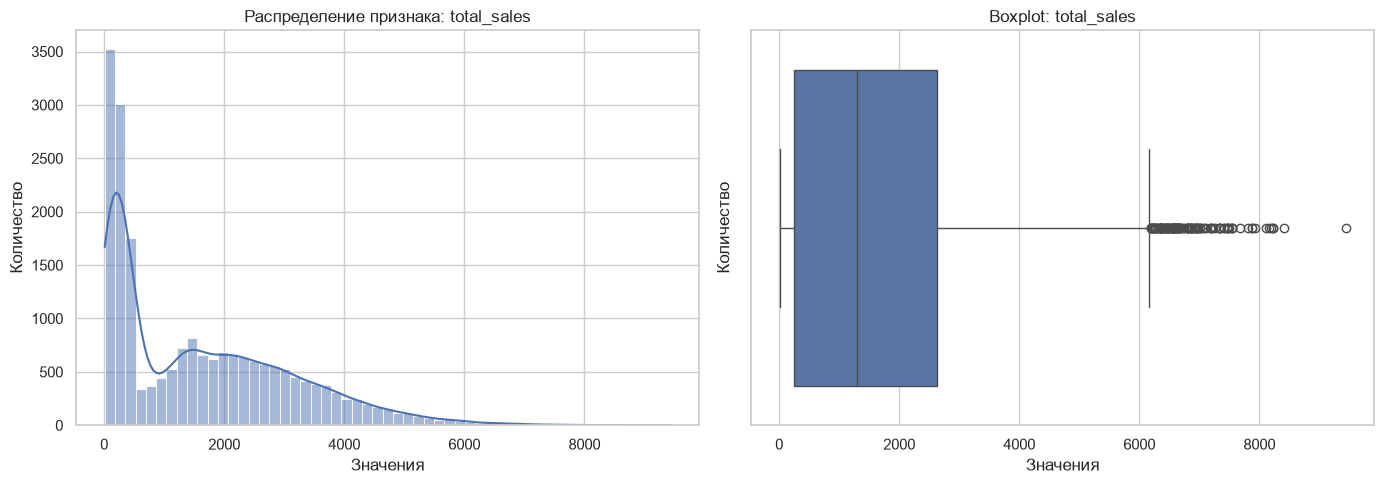

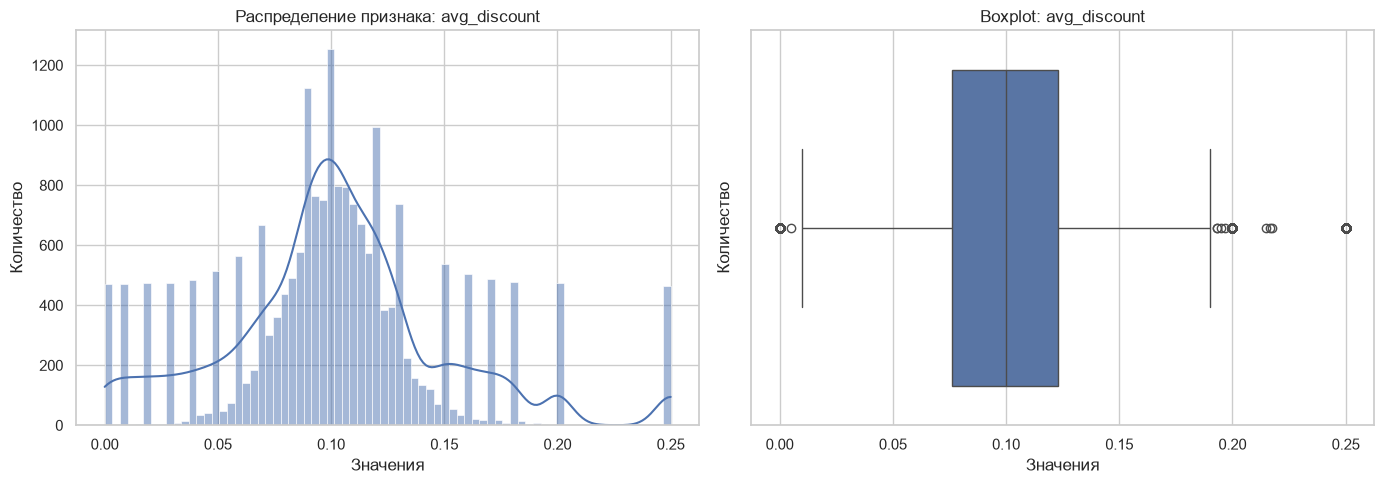

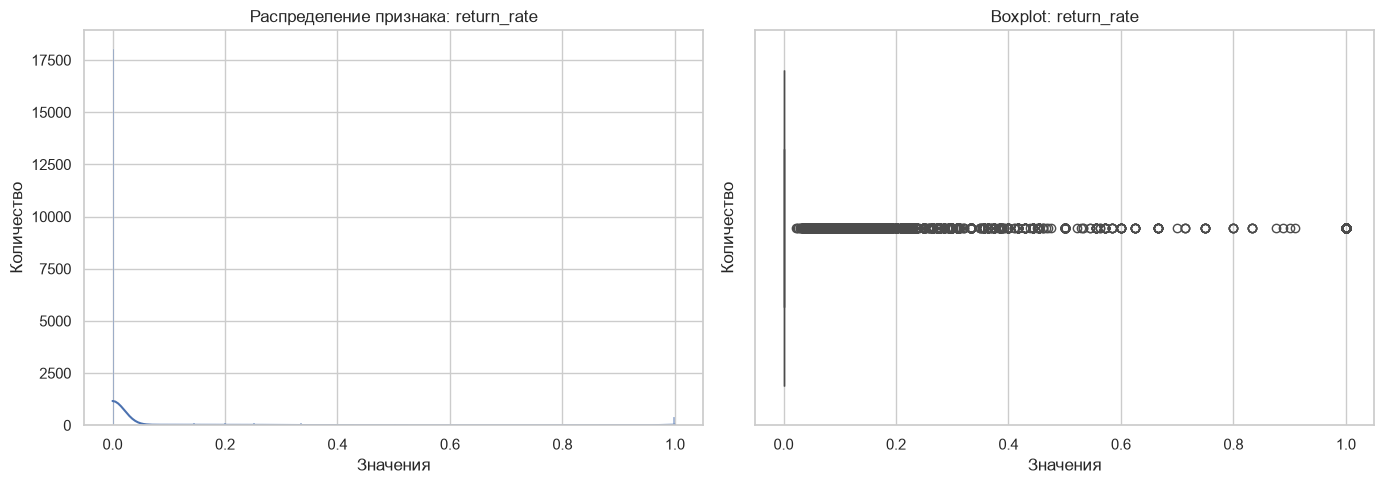

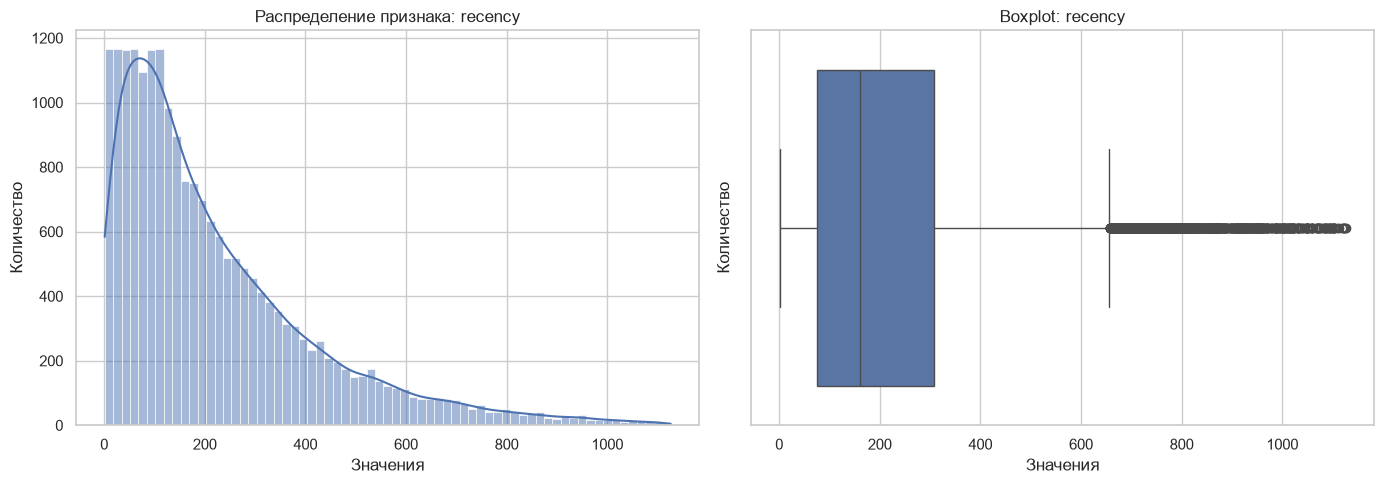

In [12]:
for col in num_cols_c:
    graphics_numerical(customers, col)

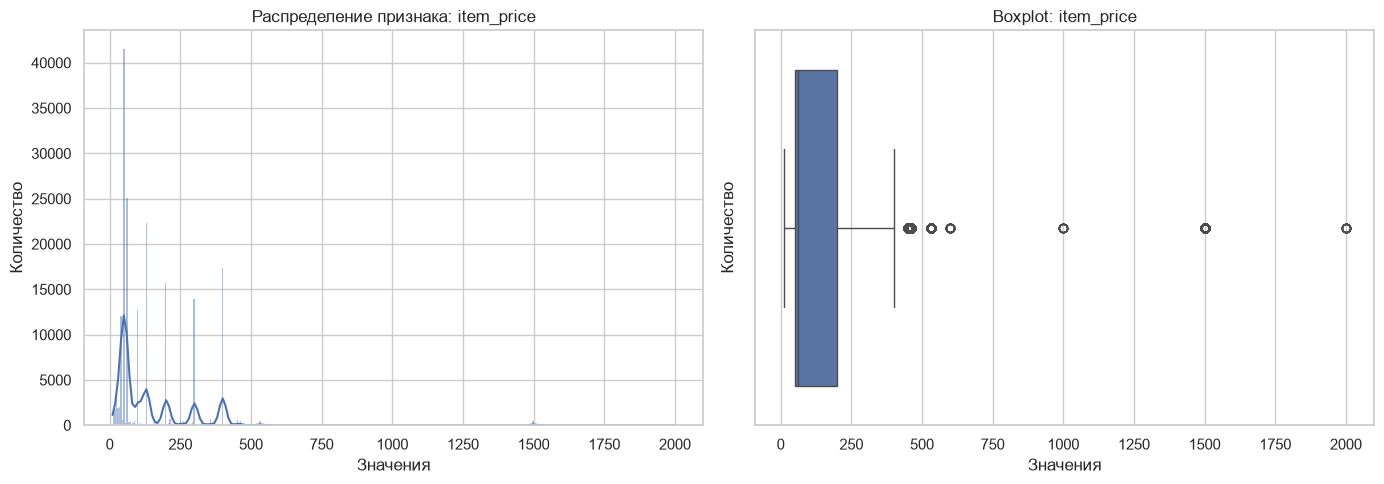

In [13]:
graphics_numerical(orders, "item_price")

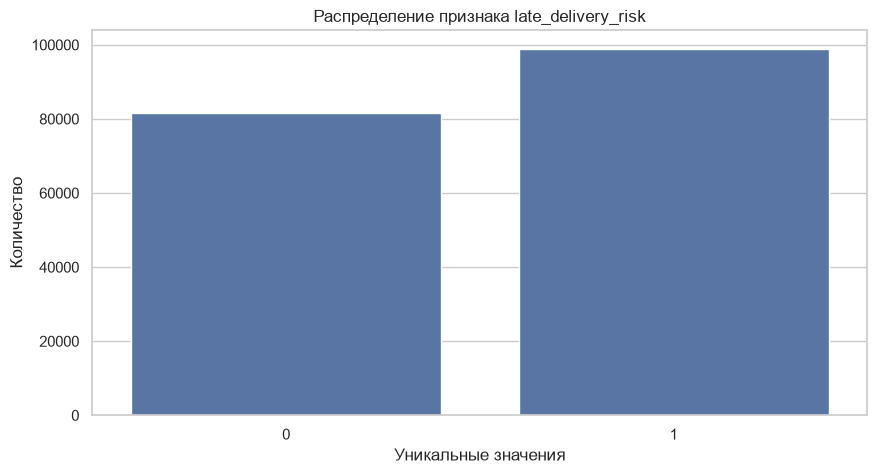

Распределение late_delivery_risk, количество и доля


,Количество,Доля
late_delivery_risk,,
1,98977,0.5483
0,81542,0.4517


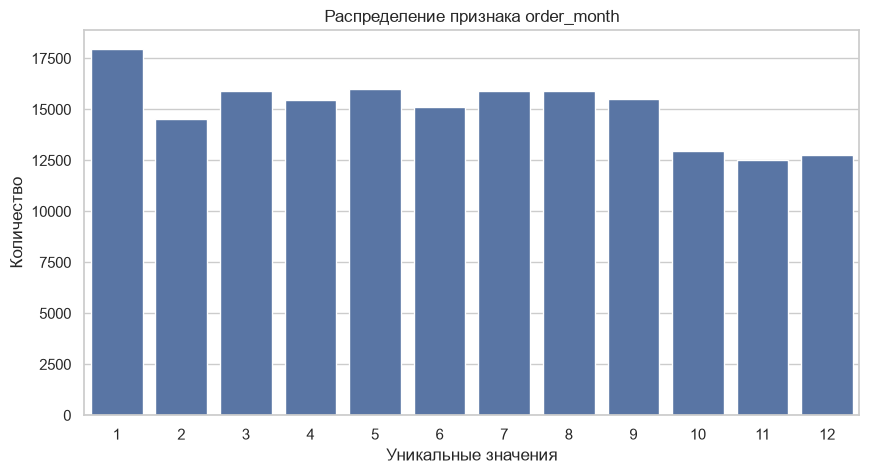

Распределение order_month, количество и доля


,Количество,Доля
order_month,,
1,17979,0.0996
5,15976,0.0885
7,15922,0.0882
3,15919,0.0882
8,15912,0.0881
9,15489,0.0858
4,15435,0.0855
6,15139,0.0839
2,14529,0.0805


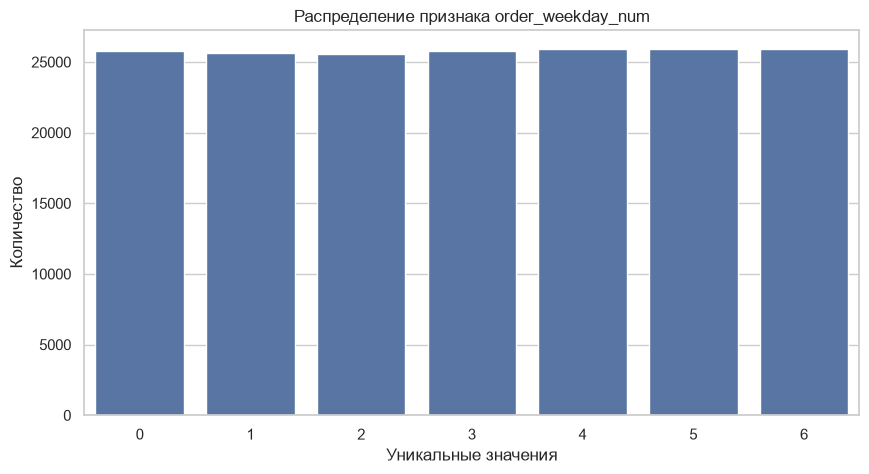

Распределение order_weekday_num, количество и доля


,Количество,Доля
order_weekday_num,,
6,25946,0.1437
4,25925,0.1436
5,25901,0.1435
0,25786,0.1428
3,25752,0.1427
1,25622,0.1419
2,25587,0.1417


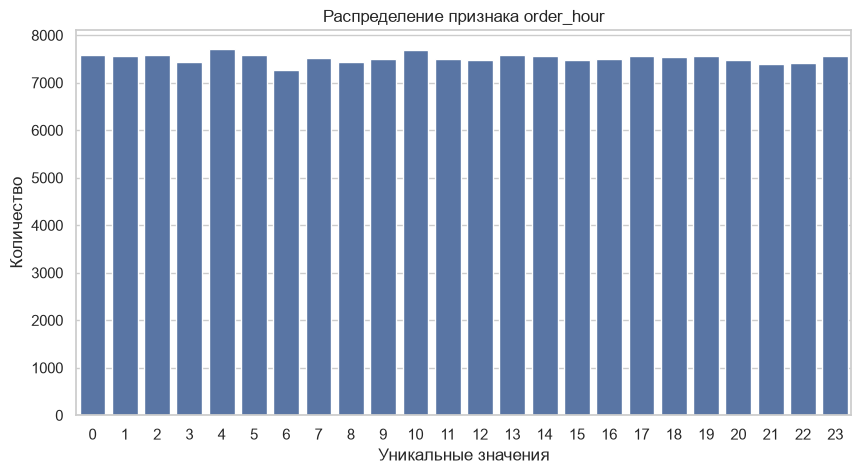

Распределение order_hour, количество и доля


,Количество,Доля
order_hour,,
4,7719,0.0428
10,7697,0.0426
5,7591,0.0421
0,7590,0.0420
13,7578,0.0420
2,7574,0.0420
23,7573,0.0420
17,7573,0.0420
1,7559,0.0419


In [14]:
for col in num_cat_o:
    graphics_numerical_cat(orders, col)

In [15]:
print(orders["shipping_mode"].value_counts(normalize=True))
orders["category_name"].value_counts(normalize=True)

shipping_mode
Standard Class   0.5969
Second Class     0.1951
First Class      0.1541
Same Day         0.0539
Name: proportion, dtype: float64


category_name
Cleats                 0.1360
Men's Footwear         0.1232
Women's Apparel        0.1165
Indoor/Outdoor Games   0.1069
Fishing                0.0960
Water Sports           0.0861
Camping & Hiking       0.0761
Cardio Equipment       0.0692
Shop By Sport          0.0608
Electronics            0.0175
Accessories            0.0099
Golf Balls             0.0082
Girls' Apparel         0.0067
Golf Gloves            0.0059
Trade-In               0.0054
Video Games            0.0046
Children's Clothing    0.0036
Women's Clothing       0.0036
Baseball & Softball    0.0035
Hockey                 0.0034
Cameras                0.0033
Toys                   0.0029
Golf Shoes             0.0029
Pet Supplies           0.0027
Crafts                 0.0027
Garden                 0.0027
DVDs                   0.0027
Computers              0.0024
Golf Apparel           0.0024
Hunting & Shooting     0.0024
Music                  0.0024
Consumer Electronics   0.0024
Boxing & MMA           0.0

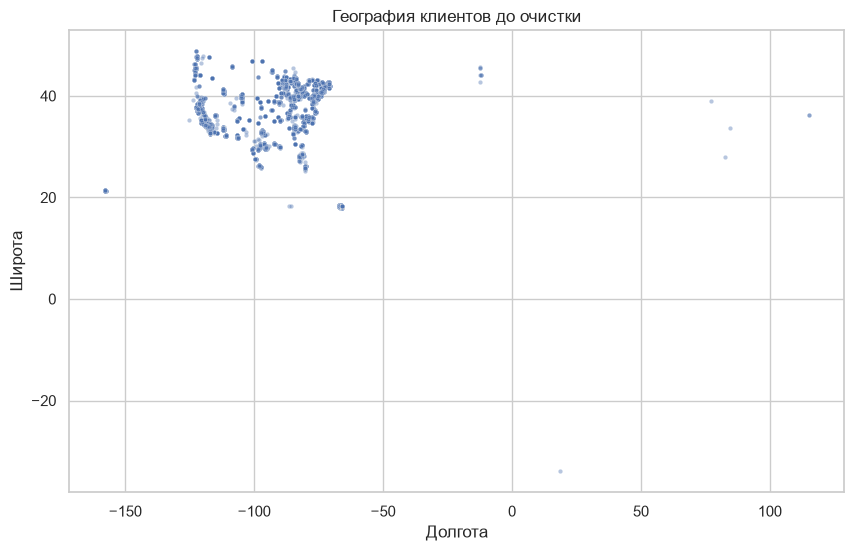

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customers,
    x="customer_lon",
    y="customer_lat",
    alpha=0.4,
    s=10
)

plt.title("География клиентов до очистки")
plt.xlabel("Долгота")
plt.ylabel("Широта")
plt.grid(True)
plt.show()

Клиентов до: 20652
Клиентов после: 20496
Удалено клиентов: 156
Заказов до: 180519
Заказов после: 179089
Удалено заказов: 1430


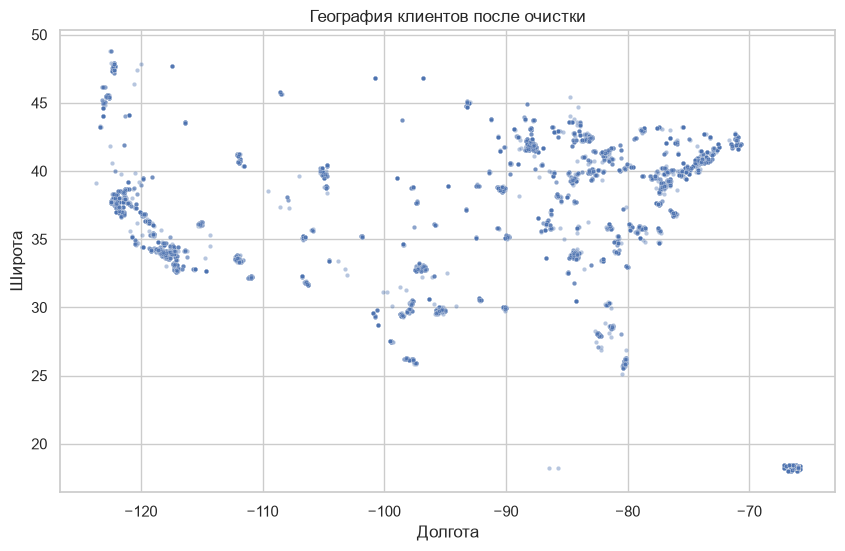

In [17]:
lon_mask = customers["customer_lon"].between(-125, -20)

bad_customer_ids = customers.loc[~lon_mask, "customer_id"]

customers_clean = customers.loc[lon_mask].copy()
orders_clean = orders.loc[
    orders["customer_id"].isin(customers_clean["customer_id"])
].copy()

print("Клиентов до:", len(customers))
print("Клиентов после:", len(customers_clean))
print("Удалено клиентов:", len(bad_customer_ids))

print("Заказов до:", len(orders))
print("Заказов после:", len(orders_clean))
print("Удалено заказов:", len(orders) - len(orders_clean))

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customers_clean,
    x="customer_lon",
    y="customer_lat",
    alpha=0.4,
    s=10
)

plt.title("География клиентов после очистки")
plt.xlabel("Долгота")
plt.ylabel("Широта")
plt.grid(True)
plt.show()

### Вывод: географические выбросы

Найдено 156 клиентов с долготой вне допустимого диапазона `[-125, -20]`; вместе с ними удалено 1430 заказов. Это около 0.76% клиентской базы, то есть очистка почти не меняет общий объем данных, но критична для кластеризации.


In [18]:
customer_distribution = pd.DataFrame({
    "metric": [
        "share_one_order_customers",
        "p75_total_orders",
        "median_recency",
        "p75_recency",
        "p95_recency",
        "share_zero_return_rate",
        "share_positive_return_rate",
    ],
    "value": [
        (customers_clean["total_orders"] == 1).mean(),
        customers_clean["total_orders"].quantile(0.75),
        customers_clean["recency"].median(),
        customers_clean["recency"].quantile(0.75),
        customers_clean["recency"].quantile(0.95),
        (customers_clean["return_rate"] == 0).mean(),
        (customers_clean["return_rate"] > 0).mean(),
    ],
})

orders_with_customers = orders_clean.merge(customers_clean, on="customer_id", how="left")
orders_with_customers["recency_bin"] = pd.cut(
    orders_with_customers["recency"],
    [0, 30, 90, 180, 365, 2000],
    labels=["<=30", "31-90", "91-180", "181-365", ">365"],
)

recency_risk = (
    orders_with_customers.groupby("recency_bin", observed=True)["late_delivery_risk"]
    .agg(orders_count="count", delay_rate="mean")
)

display(customer_distribution)
display(recency_risk)


,metric,value
0,share_one_order_customers,0.4304
1,p75_total_orders,5.0000
2,median_recency,160.0000
3,p75_recency,308.0000
4,p95_recency,640.2500
5,share_zero_return_rate,0.8728
6,share_positive_return_rate,0.1272


,orders_count,delay_rate
recency_bin,,
<=30,2041,0.5600
31-90,4080,0.5520
91-180,50069,0.5475
181-365,81208,0.5502
>365,41691,0.5447


### Вывод: структура клиентской базы

Большая часть клиентов имеет короткую историю взаимодействия: 43.02% сделали один заказ, 75% клиентов имеют не больше 5 заказов. Это ограничивает надежность персонального профиля для каждого отдельного клиента

`recency` также распределен неравномерно: медиана — 160 дней, 75-й процентиль — 308 дней, 95-й процентиль — 640 дней. В базе много клиентов, которые давно не заказывали. Однако риск задержки по группам recency меняется слабо: примерно 54.47-56.00%. Значит, давность последнего заказа сама по себе не выглядит главным фактором задержки

In [19]:
target_rate = orders_clean["late_delivery_risk"].mean()

shipping_risk = (
    orders_clean.groupby("shipping_mode")["late_delivery_risk"]
    .agg(orders_count="count", delay_rate="mean")
    .sort_values("delay_rate", ascending=False)
)

category_risk = (
    orders_clean.groupby("category_name")["late_delivery_risk"]
    .agg(orders_count="count", delay_rate="mean")
    .query("orders_count >= 1000")
    .sort_values("delay_rate", ascending=False)
)

print(f"Доля задержек после геоочистки: {target_rate:.2%}")
print("Риск задержки по режиму доставки:")
display(shipping_risk)
print("Категории с максимальным риском среди категорий с 1000+ заказов:")
display(category_risk.head(12))


Доля задержек после геоочистки: 54.83%
Риск задержки по режиму доставки:


,orders_count,delay_rate
shipping_mode,,
First Class,27582,0.9536
Second Class,34946,0.7667
Same Day,9691,0.4559
Standard Class,106870,0.3807


Категории с максимальным риском среди категорий с 1000+ заказов:


,orders_count,delay_rate
category_name,,
Accessories,1766,0.5713
Golf Gloves,1056,0.5634
Electronics,3135,0.5598
Girls' Apparel,1188,0.5530
Shop By Sport,10891,0.5516
Cleats,24374,0.5497
Fishing,17187,0.5490
Water Sports,15421,0.5481
Indoor/Outdoor Games,19149,0.5474


### Вывод: структура заказов и целевой переменной

Главный обнаруженный операционный сигнал — `shipping_mode`. Распределение риска резко отличается по режимам: `First Class` задерживается в 95.36% случаев, `Second Class` — в 76.67%, `Same Day` — в 45.59%, `Standard Class` — в 38.07%. Это контринтуитивно: более быстрые классы не выглядят более надежными. Возможная бизнес-интерпретация - быстрый режим выбирается или назначается для изначально сложных, срочных или рискованных заказов, либо SLA для таких режимов жестче


interval columns not set, guessing: ['late_delivery_risk', 'item_price', 'order_month', 'order_weekday_num', 'order_hour']


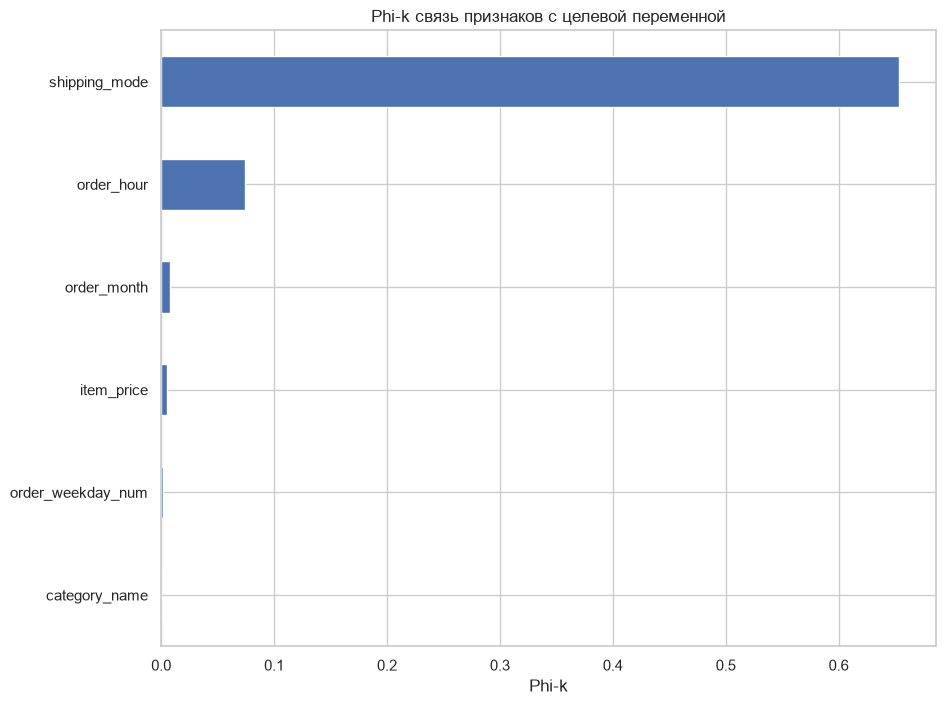

,phik_with_target
shipping_mode,0.6537
order_hour,0.0745
order_month,0.0081
item_price,0.0048
order_weekday_num,0.0017
category_name,0.0000


In [20]:
target = "late_delivery_risk"
phik_data = orders_clean.drop(columns=["order_id", "customer_id", "order_date"]).copy()

phik_corr = phik_data.phik_matrix()

target_phik = (
    phik_corr[target]
    .drop(target)
    .sort_values(ascending=False)
)

target_phik.sort_values().plot.barh(figsize=(10, 8))
plt.title("Phi-k связь признаков с целевой переменной")
plt.xlabel("Phi-k")
plt.show()

display(target_phik.to_frame("phik_with_target"))

In [21]:
orders_with_customers = orders_clean.merge(customers_clean, on="customer_id", how="left")
orders_with_customers["return_rate_bin"] = pd.cut(
    orders_with_customers["return_rate"],
    [-0.001, 0, 0.25, 0.5, 0.75, 1],
    labels=["0", "0-25%", "25-50%", "50-75%", "75-100%"],
)

return_rate_risk = (
    orders_with_customers.groupby("return_rate_bin", observed=True)["late_delivery_risk"]
    .agg(orders_count="count", delay_rate="mean")
)

display(target_phik.to_frame("phik_with_target"))
display(return_rate_risk)


,phik_with_target
shipping_mode,0.6537
order_hour,0.0745
order_month,0.0081
item_price,0.0048
order_weekday_num,0.0017
category_name,0.0000


,orders_count,delay_rate
return_rate_bin,,
0,141139,0.5708
0-25%,29024,0.5007
25-50%,7766,0.3793
50-75%,620,0.2548
75-100%,540,0.0074


### Вывод: первичная проверка гипотез по phi-k

`shipping_mode` имеет самую сильную связь с задержкой (`phi-k = 0.6537`). Это значит, что базовая модель, скорее всего, уже получит существенный сигнал из режима доставки

Остальные признаки заказа почти не объясняют риск: `order_hour` дает слабый сигнал (`0.0745`), месяц, день недели, цена и категория товара близки к нулю


##  Разделение на выборки

Разделите датафрейм с заказами на выборки. В этом проекте вам предстоит  использовать «классическое» разделение на три выборки: обучающую, валидационную и тестовую. Использовать для этого нужно не `train_test_split`, а `GroupShuffleSplit`. Он делит данные так, чтобы группы, то есть клиенты, не пересекались.

Ниже приведён пример того, как отделить часть данных для обучения, используя `customer_id` как ключ для группировки.

```python
from sklearn.model_selection import GroupShuffleSplit

# 1. Выбираем колонку, по которой будем группировать (наши "группы")
groups = df_orders['customer_id']

# 2. Инициализируем сплиттер (например, отделим 20% клиентов для теста)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

# 3. Получаем индексы для разделения
# Метод split возвращает генератор, поэтому используем next()
train_idx, test_idx = next(gss.split(df_orders, groups=groups))

# 4. Формируем выборки
df_train = df_orders.iloc[train_idx]
df_test = df_orders.iloc[test_idx]

```


1. Разделите данные из датафрейма с заказами  на три выборки  в соотношении 60:20:20.


2. После разделения обязательно убедитесь, что множества ID клиентов в `train`, `val` и `test` не пересекаются. Если один и тот же клиент попал в разные выборки, то разделение выполнено неверно.

In [ ]:
groups = orders_clean["customer_id"]
gss = GroupShuffleSplit(n_splits=1, train_size=0.6, random_state=RANDOM_STATE)

train_idx, tmp_idx = next(gss.split(orders_clean, groups=groups))

df_train = orders_clean.iloc[train_idx].copy()
df_tmp = orders_clean.iloc[tmp_idx].copy()

gss_2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=RANDOM_STATE)
val_idx, test_idx = next(gss_2.split(df_tmp, groups=df_tmp["customer_id"]))
df_val = df_tmp.iloc[val_idx].copy()
df_test = df_tmp.iloc[test_idx].copy()



In [24]:
train_customers = set(df_train["customer_id"])
val_customers = set(df_val["customer_id"])
test_customers = set(df_test["customer_id"])

print("train:", len(df_train))
print("val:", len(df_val))
print("test:", len(df_test))

print("train in val:", len(train_customers & val_customers))
print("train in test:", len(train_customers & test_customers))
print("val in test:", len(val_customers & test_customers))

train: 107721
val: 35355
test: 36013
train in val: 0
train in test: 0
val in test: 0


## Обучение базовой модели

Прежде чем проверять гипотезу о сегментации и создавать при помощи кластеризации новые признаки, необходимо зафиксировать точку отсчёта. Вам нужно понять, какое качество прогноза задержек обеспечивают стандартные модели, используя только базовую информацию о самом заказе.

1. Выберите нужные признаки — используйте колонки таблицы `orders` (`shipping_mode`, `category_name`, `item_price`, `order_hour`,  `order_weekday` и `order_month`).

2. Обучите логистическую регрессию и `CatBoostClassifier` и оцените их качество.

3. Оцените качество обеих моделей на валидационной выборке.

Напоминаем, что на этапе построения базовой модели глубокий подбор гиперпараметров необязателен.

**Дополнительное задание.** Если вы чувствуете в себе силы, вы можете попробовать базовую оптимизацию, но помните: главная прибавка к качеству ожидается от новых признаков, которые вы создадите в следующих разделах.






##  Кластеризация по признакам, связанным с местоположением



На этом этапе нужно превратить исходные координаты `customer_lat` и `customer_lon` в полезный для модели признак — логистическую зону.

**Ваши действия:**

1. Проведите корректную подготовку признаков.
2. Продумайте защиту от утечки данных.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Постройте график с полученными кластерами и отметьте центроиды.

##  Кластеризация по признакам профилей клиентов





1. Подготовьте векторы признаков — используйте пять ключевых показателей из датасета `df_customers.csv`: `recency`, `total_orders`, `total_sales`, `return_rate` и `avg_discount`.
2. Выполните предобработку данных и обеспечьте защиту от утечек.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Проанализируйте полученные кластеры: дайте статистическую характеристику и опишите самые яркие группы.
5. Визуализируйте положение кластеров с помощью t-SNE.



##  Обучение модели на новых признаках

1. Добавьте результаты кластеризаций в данные для обучения моделей.
2. Обучите финальные версии логистической регрессии и `CatBoostClassifier` на расширенном наборе данных.
3. Рассчитайте итоговые значения метрики ROC−AUC на валидационной выборке.
   

## Дополнительное задание — подбор лучшего количества кластеров

Рассмотрите количество кластеров как гиперпараметр всей системы и найти ту «степень детализации», которая даст максимальный прирост ROC-AUC.

Вы можете взять значения из списка или выбрать свои:

```python
geo_k_range = [4, 8, 12, 20]
rfm_k_range = [6, 12, 20, 30]
```



## Тестирование лучшей модели

На этом этапе вы должны убедиться, что выбранная модель сохраняет высокое качество на данных, которые она никогда не видела, и понять, какие факторы стали решающими для прогноза.

1. Выполните предсказание на тестовой выборке для лучшей модели. Рассчитайте итоговый ROC-AUC и сравните его с целевым показателем 0.75.
2. Постройте матрицу ошибок. Определите, какой тип ошибок совершает модель чаще: пропускает ли она реальные задержки или слишком часто выдаёт ложную тревогу?
3. Визуализируйте важность признаков вашей лучшей модели.
4. Проанализируйте позиции созданных вами признаков `geo_cluster` и `beh_cluster` в общем рейтинге. Стали ли они ключевыми факторами для предсказаний модели для модели или базовые параметры заказа (цена, время) остались приоритетными?

##  Выводы и рекомендации

Что нужно зафиксировать:

* **Результаты моделирования.** Укажите итоговое значение ROC-AUC на тестовой выборке. Удалось ли вам достичь целевого показателя? Насколько эффективно итоговая модель справляется с выявлением задержек по сравнению с базовыми?
* **Эффективность сегментации.** Сформулируйте вывод о полезности кластеризации. Подтвердилась ли гипотеза о том, что профиль клиента и его географическое положение влияют на риск задержки? Какие именно кластеры — географические или поведенческие — оказались более информативными для модели? Добавьте в раздел визуализации, которые вы получили, работая над проектом.
* **Технический инсайт.** Если вы экспериментировали с разным количеством  кластеров как с гиперпараметром, то укажите, какое количество кластеров K оказалось оптимальным. Кратко поясните, почему слишком большое K может вредить качеству прогноза.
* **Бизнес-рекомендации.** Предложите, как CargaPronto может использовать вашу модель в реальных операциях.